In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Anisotropy Models
To measure molecular motion, fluorescence lifetimes are collected by vertically polarizing the incident light, and the fluorescence is analyzed at vertical (parallel), magic (54.7<sup>o</sup>), and horizontal (perpendicular) angles to the incident light. This notebook will walk through anisotropy models presented in the references below. Time-correlated single photon counting data will be simulated from the models and then fit with the same model function. The fitting routines can be copied or reused for fitting to real data. 

**References:**
1. I. Emilie Steinmark, et al, "Time-Resolved Fluorescence Anisotropy of a Molecular Rotor Resolves Microscopic Viscosity Parameters in Complex Environments," *Nano-Micro-Small* **16 (22)** (2020). doi: 10.1002/smll.201907139
2. Troy C. Messina* and David S. Talaga, "Protein Free Energy Landscapes Remodeled by Ligand Binding," *Biophys. J.* **93** (2007). doi: 10.1529/biophysj.107.103911
   
## A Freely Rotating Sphere
 Magic angle fluorescence with a single fluorescence lifetime follows the form

$$A_M(t) = A e^{-t/\tau} + C$$

The vertical polarization has the form

$$A_V(t) = A_M(t) \times \left(1+ 2r(t)\right)$$

The horizontal polarization has the form

$$A_H(t) = A_M(t) \times \left(1-r(t)\right)$$

where
$$r(t) = r_o e^{-t/\theta_r}$$
							
Multiple fluorescent lifetimes ($\tau$) and multiple rotational dynamics lifetimes ($\theta_r$) may be observed, which leads to more complicated functions with many permutations available, e.g., rotations associated with all fluorescent lifetimes or rotations independently associated with each fluorescent lifetime. All of the models here can be made more complicated by mixing and adding terms.

The fit parameters for a single fluorescent lifetime and a single rotational rate would be
```python
pw[0] = irf shift magic
pw[1] = irf shift vertical
pw[2] = irf shift horizontal
pw[3] = magic background baseline
pw[4] = vertical background baseline
pw[5] = horizontal background baseline
pw[6] = A_M
pw[7] = A_V
pw[8] = A_H
pw[9] = tau
pw[10] = r0
pw[11] = theta
```

Below, we simulate fluorescence anisotropy using a Gaussian instrument response function and the freely rotating sphere model.

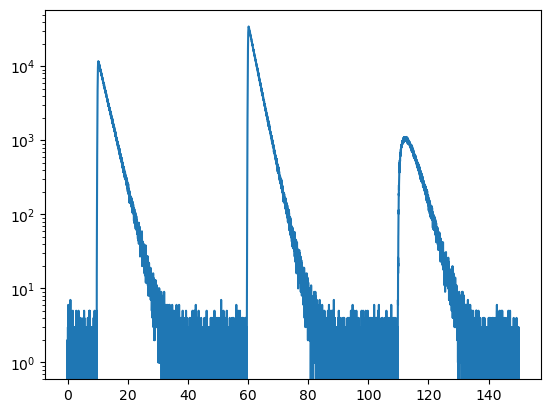

In [54]:
t = np.linspace(0, 50, 4096) #time (TAC)
big_t = np.linspace(0, 150, 4096*3) #a pseudo-time array to plot all polarizations at once.
pw = np.array([0, 0, 0, 10, 10, 10, 100000, 100000, 100000, 2.5, 1, 10]) #parameters that describe the fluorescence decays
sigma = 0.1 #IRF width
global GLOBAL_IRF #create a globally accessible IRF
GLOBAL_IRF = 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-0.5*(t-10)**2/sigma**2)
GLOBAL_IRF /= np.sum(GLOBAL_IRF)

#create the simulated data. A single array that plots with the pseudo time is returned
def make_anisotropy(t, pw):
    L = len(t)
    AM = pw[6] * np.exp(-t/pw[9]) #magic
    AV = pw[7] * np.exp(-t/pw[9])*(1+2*pw[10]*np.exp(-t/pw[11])) #vertical
    AH = pw[8] * np.exp(-t/pw[9])*(1-pw[10]*np.exp(-t/pw[11])) #horizontal
    AMc = np.convolve(GLOBAL_IRF, AM, mode='full') + pw[3] #convolve with the IRF
    AMc = AMc[0:L] #cut a single decay from the convolution
    AVc = np.convolve(GLOBAL_IRF, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    AHc = np.convolve(GLOBAL_IRF, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    return np.concatenate((AMc, AVc, AHc))

model = make_anisotropy(t, pw)
n_samples = 10000000 #how many photons to simulate
samples = np.random.choice(big_t, size=n_samples, replace=True, p=model/np.sum(model)) #sample the distribution
time = np.linspace(0, 150, 4096*3+1)
data, bin_edges = np.histogram(samples, bins=time)

plt.semilogy(bin_edges[0:len(data)],data)
plt.show()

### Fitting Anisotropy
The data above was created by sampling the model function which was created with the following parameters.
The fit parameters for a single fluorescent lifetime and a single rotational rate would be
```python
pw[0] = 0 #irf shift magic
pw[1] = 0 #irf shift vertical
pw[2] = 0 #irf shift horizontal
pw[3] = 10 #magic background baseline
pw[4] = 10 #vertical background baseline
pw[5] = 10 #horizontal background baseline
pw[6] = 1000000 #A_M
pw[7] = 1000000 #A_V
pw[8] = 1000000 #A_H
pw[9] = 2.5 #ns tau
pw[10] = 1 #r0
pw[11] = 10 # ns theta
```

Now, we'll define a fit function that minimizes the residuals through a Levenberg-Marquardt routine.

In [55]:
global NPTS
NPTS = 4096

def fit_anis_1x1(t, *args):
    pw = np.array(args[0], dtype=np.float64)
    L = len(t)
    AM = np.zeros_like(t)
    AV = np.zeros_like(t)
    AH = np.zeros_like(t)

    AM = pw[6] * np.exp(-t/pw[9])
    AV = pw[7] * np.exp(-t/pw[9])*(1+2*pw[10]*np.exp(-t/pw[11]))
    AH = pw[8] * np.exp(-t/pw[9])*(1-pw[10]*np.exp(-t/pw[11]))
    roll_irf = np.roll(GLOBAL_IRF, pw[0])#shift(GLOBAL_IRF, shift)
    AMc = np.convolve(roll_irf, AM, mode='full') + pw[3]
    AMc = AMc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[1])#shift(GLOBAL_IRF, shift)
    AVc = np.convolve(roll_irf, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[2])#shift(GLOBAL_IRF, shift)
    AHc = np.convolve(roll_irf, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    
    return np.concatenate((AMc, AVc, AHc))

def residual_function(params, x, y):
    """Computes the residuals (difference between observed and predicted y values)."""
    time = x[0:NPTS]
    predicted_y = fit_anis_1x1(time, params)
    weights = np.sqrt(y)
    weights = np.clip(weights, a_min=1, a_max=None)#make sure there are no zeros
    return (y - predicted_y)/weights

### Check the initial guess
We will assume we don't already know the parameters and insert some guesses to see an initial fit. Once we are happy with the guesses, we will run the fit routine.

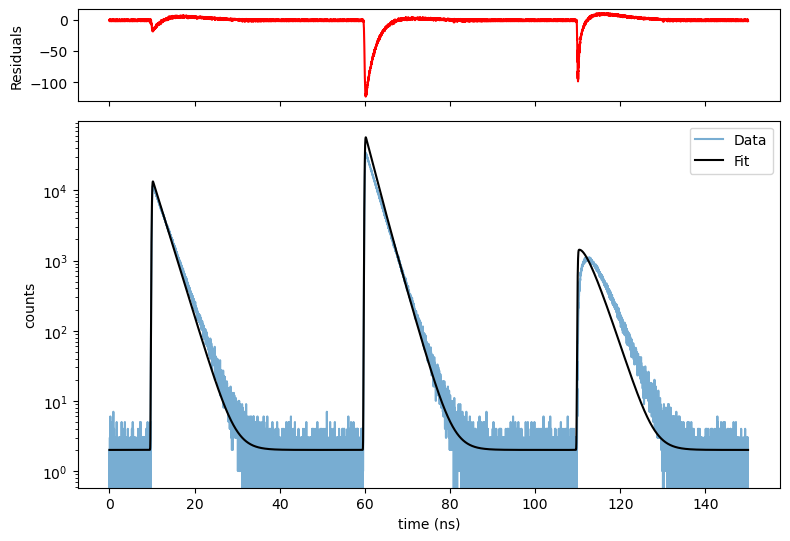

In [62]:
initial_guess = np.array([0, 0, 0, 2, 2, 2, 15000, 25000, 7000, 2.2, 0.8, 7])
testy = fit_anis_1x1(t, initial_guess)

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, (data-testy)/(np.sqrt(data)+1), 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, testy, 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Fit the data

`ftol` termination condition is satisfied.
Function evaluations 6, initial cost 1.0974e+06, final cost 5.1934e+03, first-order optimality 3.77e-03.
Optimized Fit Parmeters: [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.41038109e-01
 7.81347454e-01 8.34787009e-01 1.28192153e+04 1.28008991e+04
 1.30799171e+04 2.49211341e+00 1.00011132e+00 1.02221842e+01]
Reduced Chi Squared =  0.8461009496031224


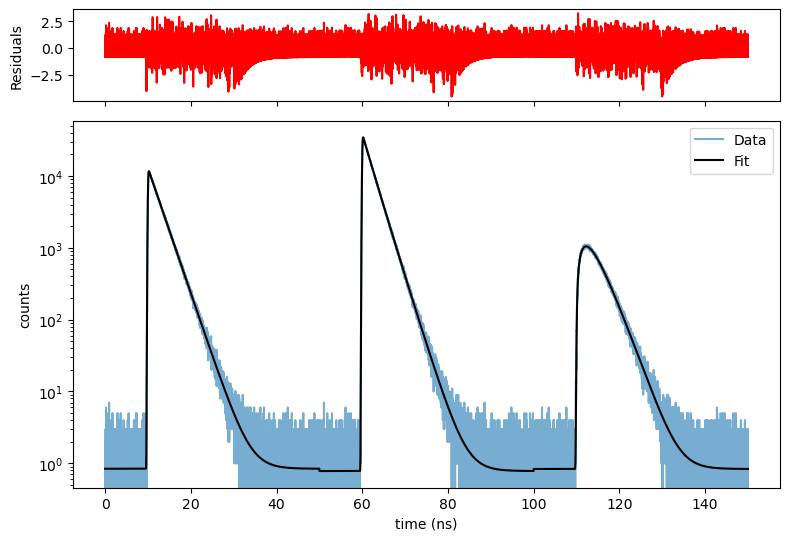

In [61]:
initial_guess = np.array([0, 0, 0, 2, 2, 2, 15000, 25000, 7000, 2.2, 0.8, 7])
result = least_squares(residual_function, initial_guess, args=(big_t, data), method='lm', verbose=1)
optimal_params = np.array(result.x)
print("Optimized Fit Parmeters:", optimal_params)
print("Reduced Chi Squared = ", np.sum(result.fun**2)/(len(data)-len(initial_guess)))

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, result.fun, 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, fit_anis_1x1(t, optimal_params), 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Wobble-Cone Model
The anisotropy term for a hindered rotation of the dye

$$r(t) = \left(r_o-r_{\infty}\right) e^{-t/\theta_r} + r_{\infty}$$
							
The fit parameters for a single fluorescent lifetime and a wobble-cone anisotropy
```python
pw[0] = irf shift magic
pw[1] = irf shift vertical
pw[2] = irf shift horizontal
pw[3] = magic background baseline
pw[4] = vertical background baseline
pw[5] = horizontal background baseline
pw[6] = A_M
pw[7] = A_V
pw[8] = A_H
pw[9] = tau
pw[10] = r0
pw[11] = theta
pw[12] = r_infinity
```

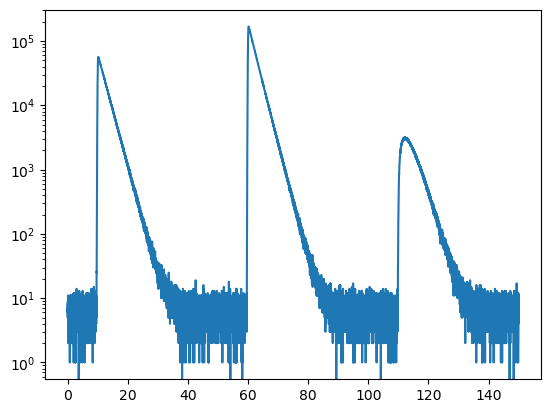

In [91]:
t = np.linspace(0, 50, 4096) #time (TAC)
big_t = np.linspace(0, 150, 4096*3) #a pseudo-time array to plot all polarizations at once.
pw = np.array([0, 0, 0, 10, 10, 10, 100000, 100000, 100000, 2.5, 1, 10, 0.4]) #parameters that describe the fluorescence decays
sigma = 0.1 #IRF width
global GLOBAL_IRF #create a globally accessible IRF
GLOBAL_IRF = 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-0.5*(t-10)**2/sigma**2)
GLOBAL_IRF /= np.sum(GLOBAL_IRF)

#create the simulated data. A single array that plots with the pseudo time is returned
def make_wobble(t, pw):
    L = len(t)
    AM = pw[6] * np.exp(-t/pw[9]) #magic
    AV = pw[7] * np.exp(-t/pw[9])*(1+2*((pw[10]-pw[12])*np.exp(-t/pw[11])+pw[12])) #vertical
    AH = pw[8] * np.exp(-t/pw[9])*(1-((pw[10]-pw[12])*np.exp(-t/pw[11])+pw[12])) #horizontal
    AMc = np.convolve(GLOBAL_IRF, AM, mode='full') + pw[3] #convolve with the IRF
    AMc = AMc[0:L] #cut a single decay from the convolution
    AVc = np.convolve(GLOBAL_IRF, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    AHc = np.convolve(GLOBAL_IRF, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    return np.concatenate((AMc, AVc, AHc))

model = make_wobble(t, pw)
n_samples = 50000000 #how many photons to simulate
samples = np.random.choice(big_t, size=n_samples, replace=True, p=model/np.sum(model)) #sample the distribution
time = np.linspace(0, 150, 4096*3+1)
data, bin_edges = np.histogram(samples, bins=time)

plt.semilogy(bin_edges[0:len(data)],data)
plt.show()

### The Fit Function for Wobble-Cone

In [84]:
global NPTS
NPTS = 4096

def fit_anis_wobble(t, *args):
    pw = np.array(args[0], dtype=np.float64)
    L = len(t)
    AM = np.zeros_like(t)
    AV = np.zeros_like(t)
    AH = np.zeros_like(t)

    AM = pw[6] * np.exp(-t/pw[9]) #magic
    AV = pw[7] * np.exp(-t/pw[9])*(1+2*((pw[10]-pw[12])*np.exp(-t/pw[11])+pw[12])) #vertical
    AH = pw[8] * np.exp(-t/pw[9])*(1-((pw[10]-pw[12])*np.exp(-t/pw[11])+pw[12])) #horizontal
    roll_irf = np.roll(GLOBAL_IRF, pw[0])#shift(GLOBAL_IRF, shift)
    AMc = np.convolve(roll_irf, AM, mode='full') + pw[3]
    AMc = AMc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[1])#shift(GLOBAL_IRF, shift)
    AVc = np.convolve(roll_irf, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[2])#shift(GLOBAL_IRF, shift)
    AHc = np.convolve(roll_irf, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    
    return np.concatenate((AMc, AVc, AHc))

def residual_wobble(params, x, y):
    """Computes the residuals (difference between observed and predicted y values)."""
    time = x[0:NPTS]
    predicted_y = fit_anis_wobble(time, params)
    weights = np.sqrt(y)
    weights = np.clip(weights, a_min=1, a_max=None)#make sure there are no zeros
    return (y - predicted_y)/weights

### Check the initial guess
We will assume we don't already know the parameters and insert some guesses to see an initial fit. Once we are happy with the guesses, we will run the fit routine.

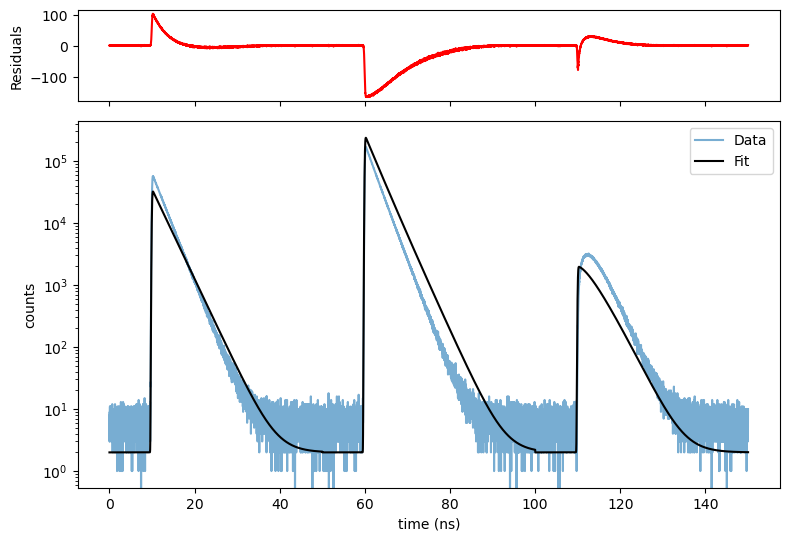

In [87]:
initial_guess = np.array([0, 0, 0, 2, 2, 2, 35000, 100000, 10000, 3, 0.8, 12, 0.1])
testy = fit_anis_wobble(t, initial_guess)

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, (data-testy)/(np.sqrt(data)+1), 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, testy, 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Fit the Wobble-Cone

`ftol` termination condition is satisfied.
Function evaluations 12, initial cost 8.8775e+06, final cost 7.0484e+03, first-order optimality 7.57e-05.
Optimized Fit Parmeters: [0.00000000e+00 0.00000000e+00 0.00000000e+00 5.10263162e+00
 4.92772351e+00 5.04611256e+00 6.26997562e+04 6.26578489e+04
 6.31927445e+04 2.49892201e+00 9.99933995e-01 1.00624740e+01
 4.02255529e-01]
Reduced Chi Squared =  1.1484159948751738


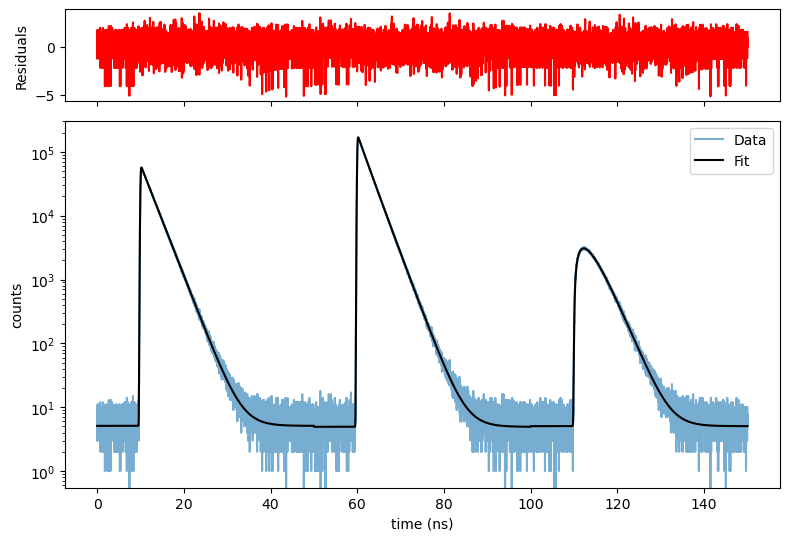

In [90]:
initial_guess = np.array([0, 0, 0, 2, 2, 2, 35000, 100000, 10000, 3, 0.8, 12, 0.1])
result = least_squares(residual_wobble, initial_guess, args=(big_t, data), method='lm', verbose=1)
optimal_params = np.array(result.x)
print("Optimized Fit Parmeters:", optimal_params)
print("Reduced Chi Squared = ", np.sum(result.fun**2)/(len(data)-len(initial_guess)))

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, result.fun, 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, fit_anis_wobble(t, optimal_params), 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Free-Free Model
The anisotropy term for a dye with two micro-environments leading to two fluorescent lifetimes and the dye freely rotates in both environments

$$r(t) = \frac{A_1 e^{-t/\tau_1}\times r_{o1} e^{-t/\theta_1} + A_2 e^{-t/\tau_2}\times r_{o2} e^{-t/\theta_2}}{A_1 e^{-t/\tau_1}+A_2 e^{-t/\tau_2}}$$
							
This model can be simplified if the free rotation time is the same in both micro-environments, i.e., $\theta_1=\theta_2$. We assume the fractional contribution of each fluorescent lifetime is equal in the magic, vertical, and horizontal channels. Therefore, we rewrite the functions. The magic angle polarization has the form

$$A_M(t) = A_M\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C$$

The vertical polarization has the form

$$A_V(t) = \left(A_V\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C\right) \times \left(1+ 2r(t)\right)$$

The horizontal polarization has the form

$$A_H(t) = \left(A_H\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C\right) \times \left(1-r(t)\right)$$

and the anisotropy term has the form

$$r(t) = \frac{f_1 e^{-t/\tau_1}\times r_{o1} e^{-t/\theta_1} + (1-f_1) e^{-t/\tau_2}\times r_{o1} e^{-t/\theta_2}}{f_1 e^{-t/\tau_1}+(1-f_1) e^{-t/\tau_2}}$$

The fit parameters for a two fluorescent lifetimes, each freely rotating in unique micro-environments are
```python
pw[0] = irf shift magic
pw[1] = irf shift vertical
pw[2] = irf shift horizontal
pw[3] = magic background baseline
pw[4] = vertical background baseline
pw[5] = horizontal background baseline
pw[6] = A_M
pw[7] = A_V
pw[8] = A_H
pw[9] = fraction of lifetime 1
pw[10] = lifetime 1
pw[11] = lifetime 2
pw[12] = r01
pw[13] = r02
pw[14] = theta 1
pw[15] = theta 2
```

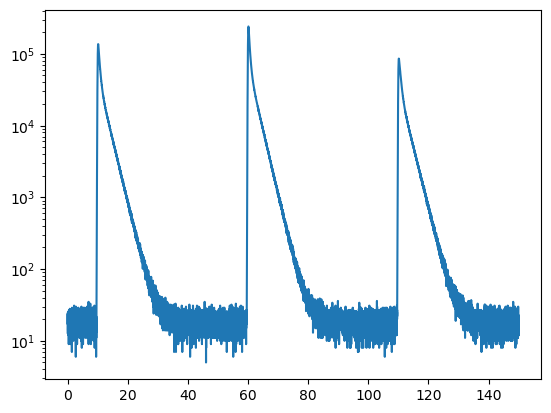

In [129]:
t = np.linspace(0, 50, 4096) #time (TAC)
big_t = np.linspace(0, 150, 4096*3) #a pseudo-time array to plot all polarizations at once.
pw = np.array([0, 0, 0, 10, 10, 10, 100000, 100000, 100000, 0.75, 0.5, 2.5, 0.5, 0.25, 1, 20]) #parameters that describe the fluorescence decays
sigma = 0.1 #IRF width
global GLOBAL_IRF #create a globally accessible IRF
GLOBAL_IRF = 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-0.5*(t-10)**2/sigma**2)
GLOBAL_IRF /= np.sum(GLOBAL_IRF)

#create the simulated data. A single array that plots with the pseudo time is returned
def make_free_free(t, pw):
    L = len(t)
    rt = (pw[9]*np.exp(-t/pw[10]) * pw[12]*np.exp(-t/pw[14]) + (1-pw[9])*np.exp(-t/pw[11]) * pw[13]*np.exp(-t/pw[15]))/(pw[9]*np.exp(-t/pw[10])+(1-pw[9])*np.exp(-t/pw[11]))
    AM = pw[6] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) #magic
    AV = pw[7] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1+2*rt) #vertical
    AH = pw[8] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1-rt) #horizontal
    AMc = np.convolve(GLOBAL_IRF, AM, mode='full') + pw[3] #convolve with the IRF
    AMc = AMc[0:L] #cut a single decay from the convolution
    AVc = np.convolve(GLOBAL_IRF, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    AHc = np.convolve(GLOBAL_IRF, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    return np.concatenate((AMc, AVc, AHc))

model = make_free_free(t, pw)
n_samples = 50000000 #how many photons to simulate
samples = np.random.choice(big_t, size=n_samples, replace=True, p=model/np.sum(model)) #sample the distribution
time = np.linspace(0, 150, 4096*3+1)
data, bin_edges = np.histogram(samples, bins=time)

plt.semilogy(bin_edges[0:len(data)],data)
plt.show()

## The Fit Function for Free-Free

In [122]:
global NPTS
NPTS = 4096

def fit_anis_free_free(t, *args):
    pw = np.array(args[0], dtype=np.float64)
    L = len(t)
    AM = np.zeros_like(t)
    AV = np.zeros_like(t)
    AH = np.zeros_like(t)

    rt = (pw[9]*np.exp(-t/pw[10]) * pw[12]*np.exp(-t/pw[14]) + (1-pw[9])*np.exp(-t/pw[11]) * pw[13]*np.exp(-t/pw[15]))/(pw[9]*np.exp(-t/pw[10])+(1-pw[9])*np.exp(-t/pw[11]))
    AM = pw[6] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) #magic
    AV = pw[7] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1+2*rt) #vertical
    AH = pw[8] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1-rt) #horizontal
    roll_irf = np.roll(GLOBAL_IRF, pw[0])#shift(GLOBAL_IRF, shift)
    AMc = np.convolve(roll_irf, AM, mode='full') + pw[3]
    AMc = AMc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[1])#shift(GLOBAL_IRF, shift)
    AVc = np.convolve(roll_irf, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[2])#shift(GLOBAL_IRF, shift)
    AHc = np.convolve(roll_irf, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    
    return np.concatenate((AMc, AVc, AHc))

def residual_free_free(params, x, y):
    """Computes the residuals (difference between observed and predicted y values)."""
    time = x[0:NPTS]
    predicted_y = fit_anis_free_free(time, params)
    weights = np.sqrt(y)
    weights = np.clip(weights, a_min=1, a_max=None)#make sure there are no zeros
    return (y - predicted_y)/weights

### Check the Initial Guess

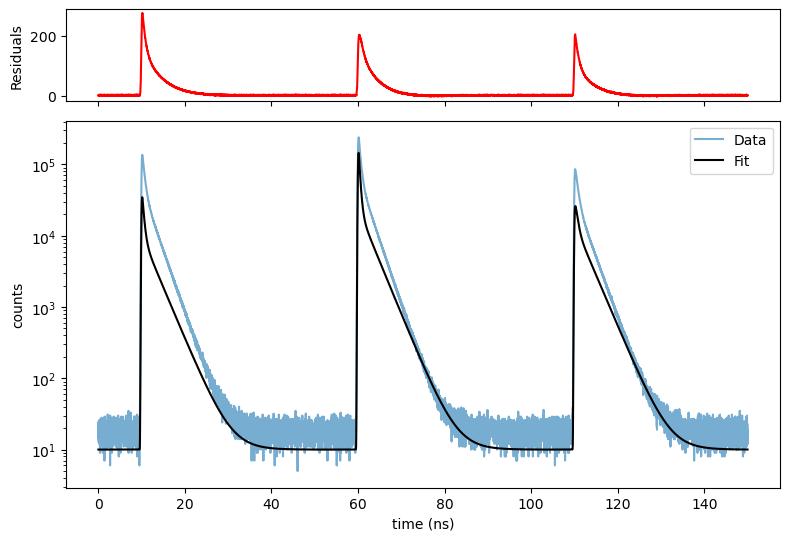

In [130]:
initial_guess = np.array([0, 0, 0, 10, 10, 10, 50000, 100000, 80000, 0.8, 0.4, 3, 0.8, 0.1, 1, 18]) #0.75, 0.5, 2.5, 0.5, 0.25, 10, 20
testy = fit_anis_free_free(t, initial_guess)

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, (data-testy)/(np.sqrt(data)+1), 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, testy, 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Fit the Free-Free Data

`ftol` termination condition is satisfied.
Function evaluations 12, initial cost 1.3397e+07, final cost 6.5426e+03, first-order optimality 3.50e-03.
Optimized Fit Parmeters: [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.73268483e+01
 1.74226906e+01 1.73460871e+01 1.84823563e+05 1.85948005e+05
 1.83760197e+05 7.49860161e-01 5.00318706e-01 2.50054800e+00
 4.96279299e-01 2.44719057e-01 9.90695658e-01 1.98116188e+01]
Reduced Chi Squared =  1.0662584899591538


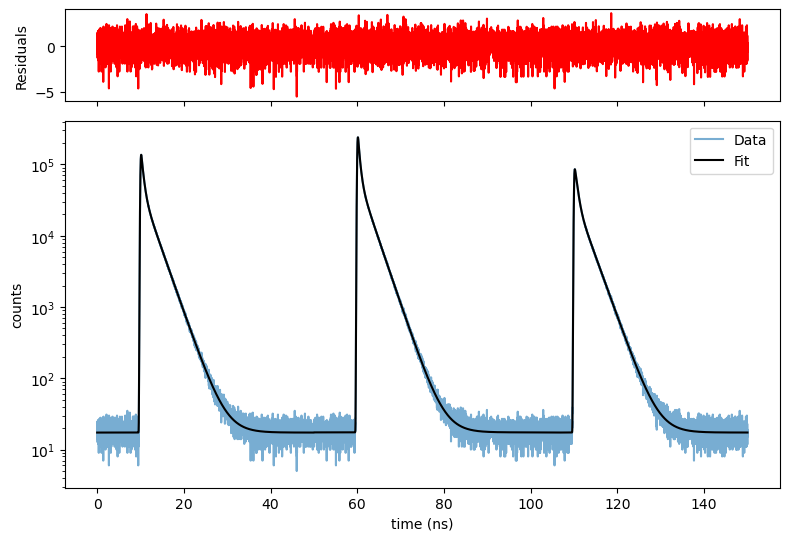

In [131]:
initial_guess = np.array([0, 0, 0, 10, 10, 10, 35000, 100000, 10000, 0.8, 0.4, 3, 0.8, 0.1, 1, 18])
result = least_squares(residual_free_free, initial_guess, args=(big_t, data), method='lm', verbose=1)
optimal_params = np.array(result.x)
print("Optimized Fit Parmeters:", optimal_params)
print("Reduced Chi Squared = ", np.sum(result.fun**2)/(len(data)-len(initial_guess)))

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, result.fun, 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, fit_anis_free_free(t, optimal_params), 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Free-Wobble Model
The anisotropy term for a dye with two micro-environments leading to two fluorescent lifetimes and the dye freely rotates in one environment but interacts with a larger rotating body in the other environment

$$r(t) = \frac{f_1 e^{-t/\tau_1}\times r_{o1} e^{-t/\theta_1} + f_2 e^{-t/\tau_2}\times r_{o2}\left[ b_2 e^{-t/\theta_2}+\left(1-b_2\right)\right]e^{-t/\theta_3}}{f_1 e^{-t/\tau_1}+f_2 e^{-t/\tau_2}}$$
							
This model can be simplified if the free rotation time is the same in both micro-environments, i.e., $\theta_1=\theta_2$. We assume the fractional contribution of each fluorescent lifetime is equal in the magic, vertical, and horizontal channels. Therefore, we rewrite the functions. The magic angle polarization has the form

$$A_M(t) = A_M\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C$$

The vertical polarization has the form

$$A_V(t) = \left(A_V\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C\right) \times \left(1+ 2r(t)\right)$$

The horizontal polarization has the form

$$A_H(t) = \left(A_H\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C\right) \times \left(1-r(t)\right)$$

The fit parameters for a two fluorescent lifetimes, each freely rotating in unique micro-environments are
```python
pw[0] = irf shift magic
pw[1] = irf shift vertical
pw[2] = irf shift horizontal
pw[3] = magic background baseline
pw[4] = vertical background baseline
pw[5] = horizontal background baseline
pw[6] = A_M
pw[7] = A_V
pw[8] = A_H
pw[9] = fraction of lifetime 1
pw[10] = lifetime 1
pw[11] = lifetime 2
pw[12] = r01
pw[13] = r02
pw[14] = b2
pw[15] = theta 1
pw[16] = theta 2
pw[17] = theta 3
```

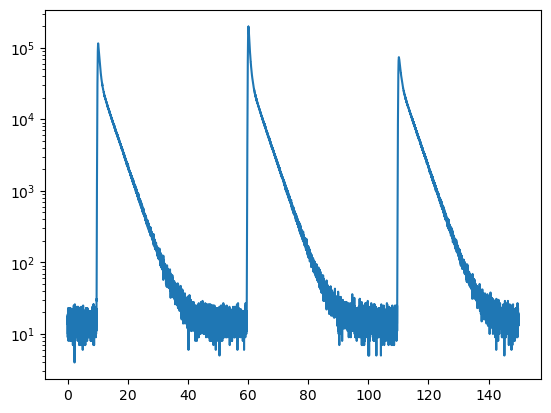

In [132]:
t = np.linspace(0, 50, 4096) #time (TAC)
big_t = np.linspace(0, 150, 4096*3) #a pseudo-time array to plot all polarizations at once.
pw = np.array([0, 0, 0, 10, 10, 10, 100000, 100000, 100000, 0.75, 0.5, 3.5, 0.5, 0.25, 0.9, 1, 2.5, 20]) #parameters that describe the fluorescence decays
sigma = 0.1 #IRF width
global GLOBAL_IRF #create a globally accessible IRF
GLOBAL_IRF = 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-0.5*(t-10)**2/sigma**2)
GLOBAL_IRF /= np.sum(GLOBAL_IRF)

#create the simulated data. A single array that plots with the pseudo time is returned
def make_free_wobble(t, pw):
    L = len(t)
    rt = (pw[9]*np.exp(-t/pw[10]) * pw[12]*np.exp(-t/pw[14]) + (1-pw[9])*np.exp(-t/pw[11]) * pw[13]*(pw[14]*np.exp(-t/pw[15])+(1-pw[14]))*np.exp(-t/pw[17]))/(pw[9]*np.exp(-t/pw[10])+(1-pw[9])*np.exp(-t/pw[11]))
    AM = pw[6] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) #magic
    AV = pw[7] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1+2*rt) #vertical
    AH = pw[8] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1-rt) #horizontal
    AMc = np.convolve(GLOBAL_IRF, AM, mode='full') + pw[3] #convolve with the IRF
    AMc = AMc[0:L] #cut a single decay from the convolution
    AVc = np.convolve(GLOBAL_IRF, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    AHc = np.convolve(GLOBAL_IRF, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    return np.concatenate((AMc, AVc, AHc))

model = make_free_wobble(t, pw)
n_samples = 50000000 #how many photons to simulate
samples = np.random.choice(big_t, size=n_samples, replace=True, p=model/np.sum(model)) #sample the distribution
time = np.linspace(0, 150, 4096*3+1)
data, bin_edges = np.histogram(samples, bins=time)

plt.semilogy(bin_edges[0:len(data)],data)
plt.show()

### The Fit Function for Free-Wobble

In [135]:
global NPTS
NPTS = 4096

def fit_anis_free_wobble(t, *args):
    pw = np.array(args[0], dtype=np.float64)
    L = len(t)
    AM = np.zeros_like(t)
    AV = np.zeros_like(t)
    AH = np.zeros_like(t)

    rt = (pw[9]*np.exp(-t/pw[10]) * pw[12]*np.exp(-t/pw[14]) + (1-pw[9])*np.exp(-t/pw[11]) * pw[13]*(pw[14]*np.exp(-t/pw[15])+(1-pw[14]))*np.exp(-t/pw[17]))/(pw[9]*np.exp(-t/pw[10])+(1-pw[9])*np.exp(-t/pw[11]))
    AM = pw[6] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) #magic
    AV = pw[7] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1+2*rt) #vertical
    AH = pw[8] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1-rt) #horizontal
    roll_irf = np.roll(GLOBAL_IRF, pw[0])#shift(GLOBAL_IRF, shift)
    AMc = np.convolve(roll_irf, AM, mode='full') + pw[3]
    AMc = AMc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[1])#shift(GLOBAL_IRF, shift)
    AVc = np.convolve(roll_irf, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[2])#shift(GLOBAL_IRF, shift)
    AHc = np.convolve(roll_irf, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    
    return np.concatenate((AMc, AVc, AHc))

def residual_free_wobble(params, x, y):
    """Computes the residuals (difference between observed and predicted y values)."""
    time = x[0:NPTS]
    predicted_y = fit_anis_free_wobble(time, params)
    weights = np.sqrt(y)
    weights = np.clip(weights, a_min=1, a_max=None)#make sure there are no zeros
    return (y - predicted_y)/weights

### Check the Initial Guess

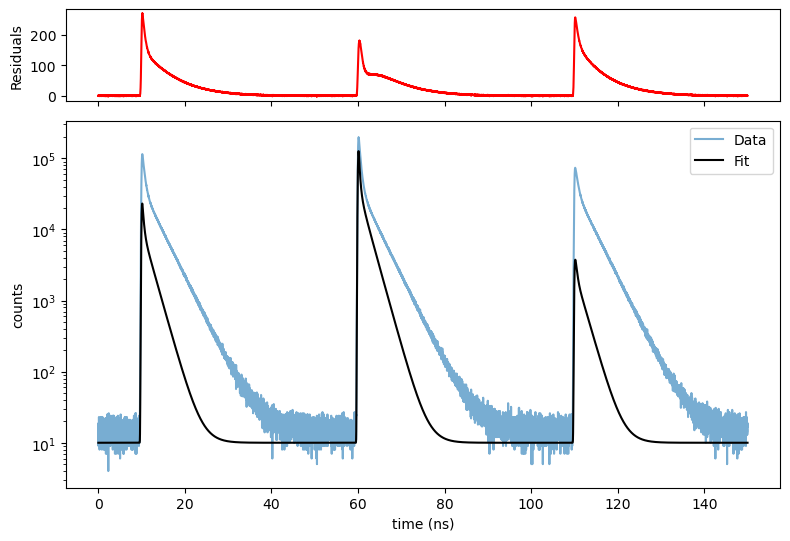

In [136]:
initial_guess = np.array([0, 0, 0, 10, 10, 10, 35000, 100000, 10000, 0.7, 0.3, 2., 0.75, 0.25, 0.5, 1, 2, 18])
testy = fit_anis_free_wobble(t, initial_guess)

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, (data-testy)/(np.sqrt(data)+1), 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, testy, 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Fit the Free-Wobble

`ftol` termination condition is satisfied.
Function evaluations 15, initial cost 1.4998e+07, final cost 6.3308e+03, first-order optimality 2.27e-04.
Optimized Fit Parmeters: [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.42327327e+01
 1.43242608e+01 1.43123555e+01 1.53976961e+05 1.53703623e+05
 1.54153085e+05 7.50226379e-01 4.99775834e-01 3.50024302e+00
 4.97911014e-01 2.57441005e-01 9.01620670e-01 9.85828363e-01
 2.00000000e+00 2.20025759e+01]
Reduced Chi Squared =  1.031918951722252


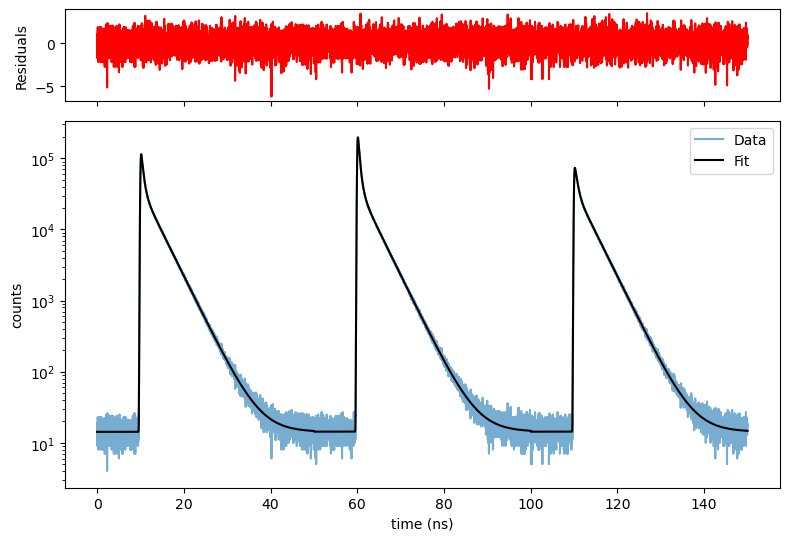

In [137]:
initial_guess = np.array([0, 0, 0, 10, 10, 10, 35000, 100000, 10000, 0.7, 0.3, 2., 0.75, 0.25, 0.5, 1, 2, 18])
result = least_squares(residual_free_wobble, initial_guess, args=(big_t, data), method='lm', verbose=1)
optimal_params = np.array(result.x)
print("Optimized Fit Parmeters:", optimal_params)
print("Reduced Chi Squared = ", np.sum(result.fun**2)/(len(data)-len(initial_guess)))

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, result.fun, 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, fit_anis_free_wobble(t, optimal_params), 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Wobble-Wobble Model
The anisotropy term for a dye with two micro-environments leading to two fluorescent lifetimes with unique hindered rotation components and the same large-body rotational interaction

$$r(t) = \frac{\left(f_1 e^{-t/\tau_1}\times r_{o1}\left[b_1 e^{-t/\theta_1}+\left(1-b_1\right)\right] + f_2 e^{-t/\tau_2}\times r_{o2}\left[b_2 e^{-t/\theta_2}+\left(1-b_2\right)\right]\right)e^{-t/\theta_p}}{f_1 e^{-t/\tau_1}+f_2 e^{-t/\tau_2}}$$
							
This model can be simplified if the free rotation time is the same in both micro-environments, i.e., $\theta_1=\theta_2$. We assume the fractional contribution of each fluorescent lifetime is equal in the magic, vertical, and horizontal channels. Therefore, we rewrite the functions. The magic angle polarization has the form

$$A_M(t) = A_M\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C$$

The vertical polarization has the form

$$A_V(t) = \left(A_V\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C\right) \times \left(1+ 2r(t)\right)$$

The horizontal polarization has the form

$$A_H(t) = \left(A_H\left(f_1 e^{-t/\tau} + \left(1-f_1\right) e^{-t/\tau}\right) + C\right) \times \left(1-r(t)\right)$$

The fit parameters for a two fluorescent lifetimes, each freely rotating in unique micro-environments are
```python
pw[0] = irf shift magic
pw[1] = irf shift vertical
pw[2] = irf shift horizontal
pw[3] = magic background baseline
pw[4] = vertical background baseline
pw[5] = horizontal background baseline
pw[6] = A_M
pw[7] = A_V
pw[8] = A_H
pw[9] = fraction of lifetime 1
pw[10] = lifetime 1
pw[11] = lifetime 2
pw[12] = r01
pw[13] = r02
pw[14] = b1
pw[15] = b2
pw[16] = theta 1
pw[17] = theta 2
pw[18] = theta p
```

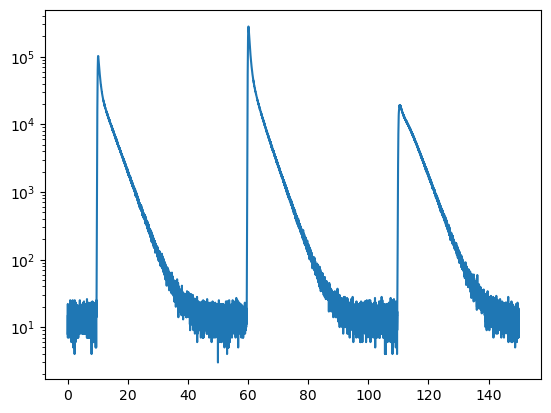

In [139]:
t = np.linspace(0, 50, 4096) #time (TAC)
big_t = np.linspace(0, 150, 4096*3) #a pseudo-time array to plot all polarizations at once.
pw = np.array([0, 0, 0, 10, 10, 10, 100000, 100000, 100000, 0.75, 0.5, 3.5, 1.0, 0.75, 0.5, 0.75, 1.0, 2.5, 20.0]) #parameters that describe the fluorescence decays
sigma = 0.1 #IRF width
global GLOBAL_IRF #create a globally accessible IRF
GLOBAL_IRF = 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-0.5*(t-10)**2/sigma**2)
GLOBAL_IRF /= np.sum(GLOBAL_IRF)

#create the simulated data. A single array that plots with the pseudo time is returned
def make_wobble_wobble(t, pw):
    L = len(t)
    rt = (pw[9]*np.exp(-t/pw[10]) * pw[12]*(pw[14]*np.exp(-t/pw[16])+(1-pw[14])) + (1-pw[9])*np.exp(-t/pw[11]) * pw[13]*(pw[15]*np.exp(-t/pw[17])+(1-pw[15])))*np.exp(-t/pw[18])/(pw[9]*np.exp(-t/pw[10])+(1-pw[9])*np.exp(-t/pw[11]))
    AM = pw[6] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) #magic
    AV = pw[7] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1+2*rt) #vertical
    AH = pw[8] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1-rt) #horizontal
    AMc = np.convolve(GLOBAL_IRF, AM, mode='full') + pw[3] #convolve with the IRF
    AMc = AMc[0:L] #cut a single decay from the convolution
    AVc = np.convolve(GLOBAL_IRF, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    AHc = np.convolve(GLOBAL_IRF, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    return np.concatenate((AMc, AVc, AHc))

model = make_wobble_wobble(t, pw)
n_samples = 50000000 #how many photons to simulate
samples = np.random.choice(big_t, size=n_samples, replace=True, p=model/np.sum(model)) #sample the distribution
time = np.linspace(0, 150, 4096*3+1)
data, bin_edges = np.histogram(samples, bins=time)

plt.semilogy(bin_edges[0:len(data)],data)
plt.show()

### The Fit Function for Wobble-Wobble

In [140]:
global NPTS
NPTS = 4096

def fit_anis_wobble_wobble(t, *args):
    pw = np.array(args[0], dtype=np.float64)
    L = len(t)
    AM = np.zeros_like(t)
    AV = np.zeros_like(t)
    AH = np.zeros_like(t)

    rt = (pw[9]*np.exp(-t/pw[10]) * pw[12]*(pw[14]*np.exp(-t/pw[16])+(1-pw[14])) + (1-pw[9])*np.exp(-t/pw[11]) * pw[13]*(pw[15]*np.exp(-t/pw[17])+(1-pw[15])))*np.exp(-t/pw[18])/(pw[9]*np.exp(-t/pw[10])+(1-pw[9])*np.exp(-t/pw[11]))
    AM = pw[6] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) #magic
    AV = pw[7] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1+2*rt) #vertical
    AH = pw[8] * (pw[9]*np.exp(-t/pw[10]) + (1-pw[9]) * np.exp(-t/pw[11])) * (1-rt) #horizontal
    roll_irf = np.roll(GLOBAL_IRF, pw[0])#shift(GLOBAL_IRF, shift)
    AMc = np.convolve(roll_irf, AM, mode='full') + pw[3]
    AMc = AMc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[1])#shift(GLOBAL_IRF, shift)
    AVc = np.convolve(roll_irf, AV, mode='full') + pw[4]
    AVc = AVc[0:L]
    roll_irf = np.roll(GLOBAL_IRF, pw[2])#shift(GLOBAL_IRF, shift)
    AHc = np.convolve(roll_irf, AH, mode='full') + pw[5]
    AHc = AHc[0:L]
    
    return np.concatenate((AMc, AVc, AHc))

def residual_wobble_wobble(params, x, y):
    """Computes the residuals (difference between observed and predicted y values)."""
    time = x[0:NPTS]
    predicted_y = fit_anis_wobble_wobble(time, params)
    weights = np.sqrt(y)
    weights = np.clip(weights, a_min=1, a_max=None)#make sure there are no zeros
    return (y - predicted_y)/weights

### Check the Initial Guess

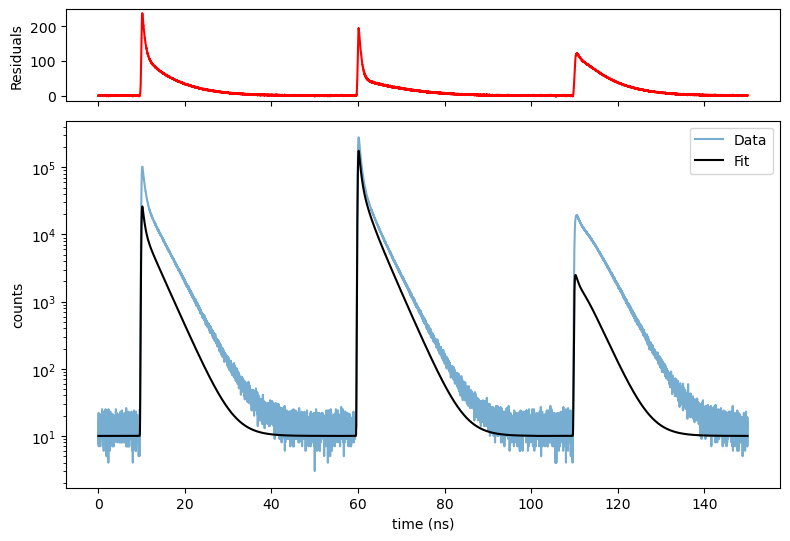

In [141]:
initial_guess = np.array([0, 0, 0, 10, 10, 10, 35000, 100000, 10000, 0.65, 0.45, 3.0, 0.8, 0.65, 0.55, 0.85, 1.0, 2.0, 18.0])
testy = fit_anis_wobble_wobble(t, initial_guess)

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, (data-testy)/(np.sqrt(data)+1), 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, testy, 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Fit the Wobble-Wobble

`ftol` termination condition is satisfied.
Function evaluations 33, initial cost 8.1661e+06, final cost 6.5422e+03, first-order optimality 7.03e-02.
Optimized Fit Parmeters: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.29550081e+01
  1.23779299e+01  1.29494332e+01  1.38011574e+05  1.37904705e+05
  1.38272975e+05  7.50153534e-01  4.99783945e-01  3.49890922e+00
  1.04378051e+00  6.23788818e-01  3.69853586e-01  8.53763675e-01
  7.17020334e-01  3.28857456e+00 -1.96534666e+07]
Reduced Chi Squared =  1.0664680135232478


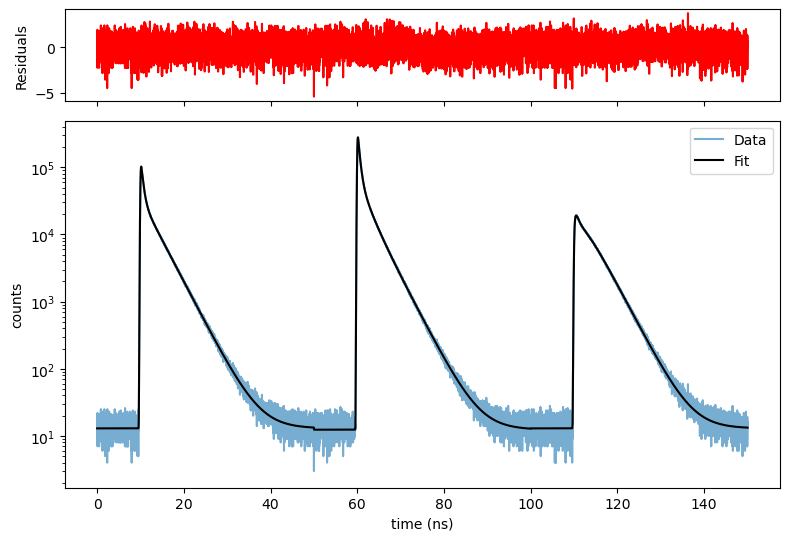

In [142]:
initial_guess = np.array([0, 0, 0, 10, 10, 10, 35000, 100000, 10000, 0.65, 0.45, 3.0, 0.8, 0.65, 0.55, 0.85, 1.0, 2.0, 18.0])
result = least_squares(residual_wobble_wobble, initial_guess, args=(big_t, data), method='lm', verbose=1)
optimal_params = np.array(result.x)
print("Optimized Fit Parmeters:", optimal_params)
print("Reduced Chi Squared = ", np.sum(result.fun**2)/(len(data)-len(initial_guess)))

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(big_t, result.fun, 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(bin_edges[0:len(data)],data, label='Data', alpha=0.6)
ax2.semilogy(big_t, fit_anis_wobble_wobble(t, optimal_params), 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()